<a href="https://colab.research.google.com/github/OGOMEGBUNAM98/April26_Rutgers-RCSB/blob/main/completed_colabs/answers003_Pandas_and_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# Project:  CodeBMB: Computational Literacy for Biochemistry and Molecular Biology Education

## Notebook: Working with data in Pandas and Numpy

**Purpose:**
Exploratory Data Analysis (EDA) is the first step in any data workflow. Before fitting models or drawing conclusions, you need to *understand* your data — its shape, its quirks, its distributions, and the relationships hiding inside it.

In this lesson you'll learn to:
- Load and inspect data with **Pandas**
- Clean and handle missing or inconsistent values
- Compute descriptive statistics with **NumPy** and **Pandas**
- Explore distributions and relationships visually
- Identify patterns that point toward deeper analysis

**Input Data:**
Data will be generated within this notebook

**Libraries:**

| Library           | Abbreviation | Source                      |
|-------------------|--------------|-----------------------------|
| pandas            | pd           | https://pandas.pydata.org/  |
| numpy             | np           | https://numpy.org/          |
| matplotlib.pyplot | plt          | https://matplotlib.org/     |
| seaborn           | sns          | https://seaborn.pydata.org/ |

**Status with Date:**
Work in Progress

**License**

<img src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/by-nc-sa.png" width="100" alttext="[CC BY-NC-SA](https://creativecommons.org/licenses/by-nc-sa/4.0/)"/>

 This license enables reusers to distribute, remix, adapt, and build upon the material in any medium or format for noncommercial purposes only, and only so long as attribution is given to the creator. If you remix, adapt, or build upon the material, you must license the modified material under identical terms. CC BY-NC-SA includes the following elements:
 BY: credit must be given to the creator.
 NC: Only noncommercial uses of the work are permitted.
 SA: Adaptations must be shared under the same terms.

---
**Authorship:** Chris Berndsen

**Acknowledgements:** This workshop is supported by NSF IUSE 2518733

**Contact Info:** Please contact us at codingBMB@gmail.com

# 0. Explanation of Colab and how to run (in notebooks for the first workshop)

To run the cell below, simply click the Run button located in that cell.

![run button image](https://github.com/wallynovak/biochemistry_seq_analysis/blob/main/images/run.png?raw=1)

NOTE: A cell is still running if you see a "stop" button with a moving circle around it. You can tell a cell has completed running as it will have a number in brackets on the left hand side (e.g. [1]) and a checkmark with the amount of time it took to run underneath it.

Please ensure every cell is done running before running the next cell.

## Section 1 — Setup: Importing Libraries

Pandas and NumPy come pre-installed in Colab. We also import **Matplotlib** and **Seaborn** for visualisation — both are pre-installed too.


Run this cell first — every section below depends on it.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

## Section 2 — Data input

In the previous exercise, the data were typed directly into the code block (`substrate_concs`) or generated as a part of the code (`velocities`). As a reminder the code is shown in the block below.

In [ ]:
# This is a list of substrate concentrations
substrate_concs = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0, 30.0, 50.0, 75.0, 100.0] #micromolar

# Key values
Km = 15.0
Vmax = 100.0

In [ ]:
# code from 002 colab
velocities = []
substrate_concs = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0, 30.0, 50.0, 75.0, 100.0]
for number in substrate_concs:
    V = Vmax * number / (Km + number)
    velocities.append(V)

# print out the velocities
print(velocities)

[6.25, 11.764705882352942, 16.666666666666668, 21.05263157894737, 28.571428571428573, 34.78260869565217, 40.0, 50.0, 57.142857142857146, 66.66666666666667, 76.92307692307692, 83.33333333333333, 86.95652173913044]


Now print the type of data for `velocities` and `substrate_concs`.

In [ ]:
# show the data type of velocities and substrate_concs
print(type(velocities))
print(type(substrate_concs))

<class 'list'>
<class 'list'>


Both `substrate_concs` and `velocities` are lists of values. Lists are simple and easy to work with, but are rarely how data are obtained from instrumentation or how we organize data. Typically, we would have `substrate_concs` and `velocities` together in the same spreadsheet as two different columns or rows because the data are linked. For every substrate concentration, there is a rate value.

---
In Python, we could organize `substrate_concs` and `velocities`  together as a **tuple**, which is an immutable but memory efficient and keeps the data pairs together. This is great if you have data connections that you need preserve during your analysis. The disadvantage of a tuple is that you cannot sort or group the data, which could hinder certain types of analysis. We could also put the data together in a **dataframe**, which is more like a spreadsheet and can be changed and sorted. Because our focus today is data analysis with Pandas, let's put `substrate_concs` and `velocities` together in a dataframe.

In [ ]:
# combine substrate_concs and velocities into a dataframe
df = pd.DataFrame({'substrate_conc': substrate_concs, # column name:list name
                   'velocity': velocities}) # column name:list name

# print the data frame
print(df)

    substrate_conc   velocity
0              1.0   6.250000
1              2.0  11.764706
2              3.0  16.666667
3              4.0  21.052632
4              6.0  28.571429
5              8.0  34.782609
6             10.0  40.000000
7             15.0  50.000000
8             20.0  57.142857
9             30.0  66.666667
10            50.0  76.923077
11            75.0  83.333333
12           100.0  86.956522


In [ ]:
df

,substrate_conc,velocity
0,1.0,6.250000
1,2.0,11.764706
2,3.0,16.666667
3,4.0,21.052632
4,6.0,28.571429
5,8.0,34.782609
6,10.0,40.000000
7,15.0,50.000000
8,20.0,57.142857
9,30.0,66.666667


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1REojMPUi5GdoMTkGECW2lCFvB9ggkaCsy7mMEnEnQ1g/edit#gid=0


The dataframe is more versatile and allows for exploration of data in different ways such showing how values vary within subpopulations. We will explore data in dataframes for the rest of this exercise.

## Section 3 — The Dataframe

Throughout this notebook we'll work with a **plant growth experiment** dataset. We will generate the data synthetically to have the data fit certain parameters that allow us to explore the capabilties of Pandas and Numpy in data analysis. In this synthetic data set, researchers measured several variables for 200 plants grown under different conditions: Researchers measured several variables for 200 plants grown under different conditions:

| Column | Description |
|---|---|
| `plant_id` | Unique identifier |
| `species` | Plant species (A, B, or C) |
| `light_hours` | Daily light exposure (hours) |
| `water_ml` | Daily water given (ml) |
| `fertilizer_g` | Fertiliser applied (grams) |
| `temperature_c` | Average ambient temperature (°C) |
| `height_cm` | Plant height after 30 days (cm) |
| `leaf_count` | Number of leaves after 30 days |
| `health_score` | Researcher-assigned health rating (1–10) |

We'll generate this dataset in the next code block so the notebook is fully self-contained. There may be some variance from run to run.

In [ ]:
#@title Create the dataset

np.random.seed()  # For reproducibility
n = 200

species      = np.random.choice(["A", "B", "C"], size=n, p=[0.4, 0.35, 0.25])
light_hours  = np.random.uniform(4, 14, size=n).round(1)
water_ml     = np.random.normal(250, 50, size=n).clip(80, 450).round(0)
fertilizer_g = np.random.exponential(scale=5, size=n).clip(0, 25).round(1)
temperature_c = np.random.normal(22, 4, size=n).round(1)

# Height depends on light, water, fertiliser, temperature, and species
species_bonus = {"A": 0, "B": 8, "C": -5}
height_cm = (
    10
    + 2.1  * light_hours
    + 0.05 * water_ml
    + 1.9  * fertilizer_g
    - 0.3  * (temperature_c - 22) ** 2   # peaks near 22 °C
    + np.array([species_bonus[s] for s in species])
    + np.random.normal(0, 4, size=n)
).clip(5, None).round(1)

leaf_count = (
    3 + 0.4 * light_hours + 0.008 * water_ml + 0.2 * fertilizer_g
    + np.array([species_bonus[s] * 0.15 for s in species])
    + np.random.normal(0, 1.5, size=n)
).clip(1, None).round(0).astype(int)

health_score = (
    1 + 0.25 * light_hours + 0.003 * water_ml + 0.05 * fertilizer_g
    - 0.04 * (temperature_c - 22) ** 2
    + np.random.normal(0, 0.8, size=n)
).clip(1, 10).round(1)

df = pd.DataFrame({
    "plant_id":     range(1, n + 1),
    "species":      species,
    "light_hours":  light_hours,
    "water_ml":     water_ml,
    "fertilizer_g": fertilizer_g,
    "temperature_c":temperature_c,
    "height_cm":    height_cm,
    "leaf_count":   leaf_count,
    "health_score": health_score,
})

# Inject ~5% missing values into water_ml and health_score to practise cleaning
missing_idx_w = np.random.choice(df.index, size=13, replace=False)
missing_idx_h = np.random.choice(df.index, size=8, replace=False)
df.loc[missing_idx_w, "water_ml"]     = np.nan
df.loc[missing_idx_h, "health_score"] = np.nan

print(f"Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset created: 200 rows × 9 columns


## Section 4 — First Look at the Data

The very first thing to do with any new dataset is simply *look* at it. The Python package Pandas is a commonly used package for working with data in dataframes and provides several methods for understanding the dataset structure and statistics.

---

To use a method with a data frame object in Pandas, we type the name of the dataframe (`df` in this exercise), followed by a period and the name of the method. The **Method** column of the table below shows how these commands are structured.  

| Method | What it shows |
|---|---|
| `df.head()` | First *n* rows (default 5) |
| `df.tail()` | Last *n* rows |
| `df.shape` | `(rows, columns)` |
| `df.columns` | List of column names |
| `df.dtypes` | Data type of each column |
| `df.info()` | Compact summary including non-null counts |

Run each cell below and read the output carefully.

In [ ]:
# We can act on the dataframe (df) using . followed by the action (head, tail, sum) as shown in table above
## Add the code from above to show the first 5 rows sometimes called the head
df.head(5)

,plant_id,species,light_hours,water_ml,fertilizer_g,temperature_c,height_cm,leaf_count,health_score
0,1,A,9.9,265.0,0.6,22.4,41.5,8,5.3
1,2,B,13.4,255.0,19.5,18.1,90.0,16,5.2
2,3,C,13.2,203.0,2.1,18.2,37.1,9,NaN
3,4,A,11.5,NaN,1.9,21.4,53.0,11,5.5
4,5,C,6.0,260.0,1.3,18.2,25.0,7,2.0


In [ ]:
# List of the column names in the data frame
df.columns

Index(['plant_id', 'species', 'light_hours', 'water_ml', 'fertilizer_g',
       'temperature_c', 'height_cm', 'leaf_count', 'health_score'],
      dtype='object')

In [ ]:
# Print the data types for each column in the data frame
df.dtypes

,0
plant_id,int64
species,object
light_hours,float64
water_ml,float64
fertilizer_g,float64
temperature_c,float64
height_cm,float64
leaf_count,int64
health_score,float64


In [ ]:
# Print the info for the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   plant_id       200 non-null    int64  
 1   species        200 non-null    object 
 2   light_hours    200 non-null    float64
 3   water_ml       187 non-null    float64
 4   fertilizer_g   200 non-null    float64
 5   temperature_c  200 non-null    float64
 6   height_cm      200 non-null    float64
 7   leaf_count     200 non-null    int64  
 8   health_score   192 non-null    float64
dtypes: float64(6), int64(2), object(1)
memory usage: 14.2+ KB


Notice the Non-Null Count column from this last output, specifically when the non-null is less than 200. When the value is less than 200, it means that there are missing data. We will address this issue in Section 5.



---


## Section 5 — Descriptive Statistics

Descriptive statistics summarise the central tendency, spread, and shape of each variable. They're the fastest way to get a quantitative feel for your data.

Notice the command structure shown in the **Pandas/NumPy** column of the table below. Pandas uses the dataframe name, while NumPy uses the package reference (`np`) followed by the method.

### Key statistics to know:

| Method | Meaning | Pandas | NumPy|
|---|---|---|---|
| **Mean** | Average value | `df.mean()` |  `np.mean()` |
| **Median** | Middle value (50th percentile) | `df.median()` | `np.median()` |
| **Std dev** | Spread around the mean | `df.std()` | `np.std()`  |
| **Min / Max** | Extreme values | `df.min()` or `df.max()` |
| **Percentiles** | Value at the *p*th rank | `df.quantile(p)` | `np.percentile()` |
| **Skewness** | Asymmetry of distribution | `df.skew()` |
| **Kurtosis** | Heaviness of tails | `df.kurt()` |
|**Describe** | Basic statistics in one command | `df.describe` |

---


In [ ]:
# calculate the mean values of the dataframe
df.mean()

TypeError: Could not convert ['ABCACCBAABAAABBAABABACBACBCCABBACACACBBCACAABBABCAAACBBAABCCBAAAACACAABABACCBBCACCCABCBABBACBACBABABABCCBBBAABAAAABBAABABACBBCBAAAAABCAAACCAAACACACCABCBAAABAABAABCAACCBBBCCAABBACAACBAAABBBAABBCAAAABCC'] to numeric

The reason we get an error here is because there are non-numeric data in the dataframe which we cannot use to calulcate a mean. Let's try a general method for looking at the data and then we can work to understand how we can calculate mean values.

In [ ]:
# df.describe() gives count, mean, std, min, quartiles, max in one command
## fill in the .describe() code
df.describe()

,plant_id,light_hours,water_ml,fertilizer_g,temperature_c,height_cm,leaf_count,health_score
count,200.000000,200.000000,187.000000,200.000000,200.000000,200.000000,200.0000,192.000000
mean,100.500000,9.055000,254.363636,5.693000,21.884000,48.525500,9.9400,3.650521
std,57.879185,2.792484,46.736925,5.437433,4.195289,15.335232,2.4549,1.320043
min,1.000000,4.000000,123.000000,0.000000,11.300000,8.900000,4.0000,1.000000
25%,50.750000,6.775000,222.000000,1.500000,19.200000,38.950000,8.0000,2.775000
50%,100.500000,9.050000,255.000000,3.850000,22.150000,48.100000,10.0000,3.800000
75%,150.250000,11.425000,284.500000,8.750000,24.725000,58.425000,11.0000,4.500000
max,200.000000,14.000000,399.000000,25.000000,32.700000,90.000000,16.0000,6.600000


### Statistics for a single column

Calculating these statistics on a whole dataframe level is useful for getting the big picture, but what if we wanted to explore just a single column of data?

In this case we need to indicate the column in single brackets and quotes like below:

`df["light_hours"].mean()`

Let's try exploring the different statistics on a single column. If you need a reminder the column names are listed in Section 2 above.

In [ ]:
# calculate the mean value for the species column in df
df["species"].mean()

TypeError: Could not convert string 'ABCACCBAABAAABBAABABACBACBCCABBACACACBBCACAABBABCAAACBBAABCCBAAAACACAABABACCBBCACCCABCBABBACBACBABABABCCBBBAABAAAABBAABABACBBCBAAAAABCAAACCAAACACACCABCBAAABAABAABCAACCBBBCCAABBACAACBAAABBBAABBCAAAABCC' to numeric

In [ ]:
# use the describe function for the leaf_count column of df
df["leaf_count"].describe()

,leaf_count
count,200.0000
mean,9.9400
std,2.4549
min,4.0000
25%,8.0000
50%,10.0000
75%,11.0000
max,16.0000


In [ ]:
# calculate the mean value for the water_ml column in df
df["water_ml"].mean()

np.float64(254.36363636363637)

Below we use the print function in addition to the statistics code. Compare the style and information in the output below to the outputs without the print function above.

In [ ]:
# print the mean value in the water_ml column of df
print(df["water_ml"].mean())

254.36363636363637


Let's combine these methods with f-printing as we learned in the 002 colab.

Let's create a statement which incorporates our `df[water_ml].mean()`.




In [ ]:
# make an f-printing statement incorporating df["water_ml"].mean()
print(f"The mean value for water_ml is {df['water_ml'].mean():.2f} ml.")

The mean value for water_ml is 254.36 ml.


You can further create a summary data frame of the columns of interest. Further, these statistics can be calculated from multiple columns of the dataframe at once.

- First create a list of the columns you want to summarize.

- Then create a pandas dataframe with your columns named for the statistic of interest (e.g. mean or standard deviation.

- In each column of this new dataframe, use the column statistics as you did above, but put your list name in the brackets.

See the example below

In [ ]:
# Create a list of numeric columns from the data
numeric_cols = ["light_hours", "water_ml", "fertilizer_g", "leaf_count"]

# calculate the statistics directly into the dataframe
## notice the list name is used in the brackets
stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std": df[numeric_cols].std(),
    })

# show the data
print(stats)

                    Mean  Median        Std
light_hours     9.055000    9.05   2.792484
water_ml      254.363636  255.00  46.736925
fertilizer_g    5.693000    3.85   5.437433
leaf_count      9.940000   10.00   2.454900


Notice that the mean values have a lot of decimal places. In chemistry and many other fields there is the concept of significant figures and that not all decimal places have meaning or are siginficant depending on your measurement methods, and this propagates into the analysis.

Let's use the `.round()` function to reduce the number of decimal places.

In [ ]:
# show the data and replace the ______ with .round(1) to round the number to the first the decimal place
print(stats.round(1))

               Mean  Median   Std
light_hours     9.1     9.0   2.8
water_ml      254.4   255.0  46.7
fertilizer_g    5.7     3.8   5.4
leaf_count      9.9    10.0   2.5


## Section 6 — Grouped Statistics with `groupby`

So far we've looked at the whole dataset and individual columns. But there are often interesting insights that come from comparing **subgroups** and the relationship between categories of data. This could be data comparing growth between species in the same experiment or enzyme variant data. In the data set in this colab, we will compare the stats between the the three plant species.

Here's how the process works:

1.   `groupby` splits a DataFrame by a **categorical** column (*species* in our example)
2.    Then we select specific data columns that we want to compare amongst the species. (Let's use *height_cm* and *leaf_count*.)
3.    Use the `.agg()` action to calculate the mean, median, standard deviation, and count on each groups.
4.    `.round(3)` these results to three decimal places.

This all happens in one step in the code below. So let's break it into the parts before we run the code:



- `df.group_by("species")` : groups the data by species

- `[["height_cm", "leaf_count"]].agg(` : indicates which columns to group by species

- `["mean", "median", "std", "count"]` : within the `.agg()` function indicates the statistics to calculate

- `.round(3)` : rounds all the answers to 3 decimal places.

When we print the species_summary data, it produces the aggregated results for each of the selected columns, further divided by species.

In [ ]:
# Summary statistics per species
##
species_summary = df.groupby("species")[["height_cm", "leaf_count"]].agg(["mean", "median", "std", "count"]).round(3)

print(species_summary)

        height_cm                      leaf_count                    
             mean median     std count       mean median    std count
species                                                              
A          46.483   45.7  14.761    89      9.775   10.0  2.183    89
B          56.684   55.9  13.736    62     11.339   11.0  2.354    62
C          41.912   41.4  14.050    49      8.469    8.0  2.103    49


## Section 7 — Exploring Distributions

A summary statistic like the mean collapses an entire distribution into one number. However, not all data are normal, therefore it is often useful to visualize the the distribution of data values.

Visualising the full distribution reveals:
- Is the data roughly **normal** (bell-shaped)?
- Is it **skewed** — a long tail on one side?
- Are there **multiple peaks** (bimodal/multimodal)?
- Are there **outliers** — extreme values far from the bulk?

These features matter because many statistical methods assume a certain distribution shape.

---

In this situation we will use the Matplotlib package to generate a histogram of the data columns.

Like we have seen previously, you can indicate the dataframe followed by a `.` and a function to generate the plot. Here we type `df.hist()`.



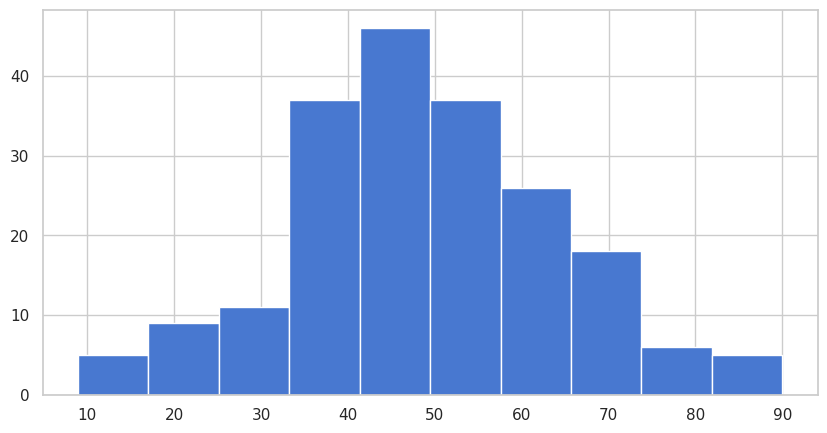

In [ ]:
# Generate histograms for columns
df["height_cm"].hist()

# show the plot
plt.show()

## Section 8 — Exploring Categorical Variables

Categorical variables don't have a natural numeric order — they represent **groups or labels**. Our dataset has one, *species* which has three different entries A, B, and C.

Since there are no numbers, it is not impossible to calculate a mean or median from the data, but we can count how many of each species there is using `.value_counts()`.

In [ ]:
# value_counts() is the categorical equivalent of describe()
species_counts = df["species"].value_counts()

print(species_counts)

species
A    89
B    62
C    49
Name: count, dtype: int64


---

## Section 9 — Finding & Handling Missing Data


Missing data is almost universal in real datasets. Pandas represents missing values as `NaN` (Not a Number). Ignoring them can silently distort your analysis, so the first cleaning step is always to **find, understand, then decide** what to do.

### Three strategies for missing values:

| Strategy | When you might use it | How often to use this |
|---|---|---|
| **Drop rows** (`dropna`) | Few rows affected; missingness is random | Recommended |
| **Fill with a statistic** (`fillna`) | Losing the entire row would hurt data analysis, use mean/median/mode | Use sparingly|
| **Forward/backward fill** | Time-series data with a natural order | Use sparingly |


In [ ]:
# Count missing values per column
## df.isnull() selects the NaN in the data, the .sum() then totals the number
missing = df.isnull().sum()



# now we will calculate the average number of NaN per column and convert it to a percentage
pct_missing = (df.isnull().mean() * 100)



# create a new data frame called missing_report which has two columns showing the # missing and the percentage
missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %":     pct_missing
})



# print the categories that are missing values
print(missing_report)

               Missing Count  Missing %
plant_id                   0        0.0
species                    0        0.0
light_hours                0        0.0
water_ml                  13        6.5
fertilizer_g               0        0.0
temperature_c              0        0.0
height_cm                  0        0.0
leaf_count                 0        0.0
health_score               8        4.0


In [ ]:
# print the missing data
# print(df[df.isna().any(axis=1)])

# create a new dataframe that excludes the missing data
df_clean = df.dropna()

# print the new dataframe
print(df_clean.head(6))

   plant_id species  light_hours  water_ml  fertilizer_g  temperature_c  \
0         1       A          9.9     265.0           0.6           22.4   
1         2       B         13.4     255.0          19.5           18.1   
4         5       C          6.0     260.0           1.3           18.2   
5         6       C          7.9     265.0           0.3           28.4   
6         7       B          8.2     240.0           3.0           26.2   
7         8       A         13.2     294.0           9.8           17.1   

   height_cm  leaf_count  health_score  
0       41.5           8           5.3  
1       90.0          16           5.2  
4       25.0           7           2.0  
5       22.4           9           2.5  
6       51.0          10           2.3  
7       59.3          12           6.2  


## Section 10 — Making new columns from the existing data

Frequently, we do further calculations on data to produce a more meaningful result. Common examples are:
- **Ratios** — Making ratios of the data to look at relative magnitudes
- **Binning** — turn a continuous variable into categories or reduce the complexity of a variable
- **Transformations** — log, sqrt, square to linearise curved relationships
- **Arithmetic** - Do simple math ( * / + - ) on one or more columns such as a background correction

---

Using the code we already have seen, we can do this simply with pandas. For example, let's calculate the ratio of height to the number of leaves and call it `height_per_leaf` to determine if taller plants have more leaves per centimeter. We could do that using the code below.

In [ ]:
# create a new column (height_per_leaf) from height_cm and leaf_count
df["height_per_leaf"] = (df["height_cm"] / df["leaf_count"])

# create a list of columns so we can see the data and result columns
# replace _______ with the columns above, remember to put each column in "" and separate wth a comma
columns = ["height_cm", "leaf_count", "height_per_leaf"]

# print the data
print(df[columns].head(5).round(2))

   height_cm  leaf_count  height_per_leaf
0       41.5           8             5.19
1       90.0          16             5.62
2       37.1           9             4.12
3       53.0          11             4.82
4       25.0           7             3.57


In this code, we identify the columns and then tell pandas what to call the new column in the dataframe.

Practice with this idea a bit more below following the comment prompts in the code block.

In [ ]:
# Multiply light_hours and water_ml to create the light_x_water column in the dataframe
df["light_x_water"] = df["light_hours"] * df["water_ml"]

# print the data
print(df[["light_hours", "water_ml", "light_x_water"]].head(5).round(2))



   light_hours  water_ml  light_x_water
0          9.9     265.0         2623.5
1         13.4     255.0         3417.0
2         13.2     203.0         2679.6
3         11.5       NaN            NaN
4          6.0     260.0         1560.0


In [ ]:
# Divide height_cm by temperature_c to show the relationship between height and temperature
# in a column called height_temp
df["height_temp"] = df["height_cm"] / df["temperature_c"]

# print the data
print(df[["height_cm", "temperature_c", "height_temp"]].head(5).round(2))


   height_cm  temperature_c  height_temp
0       41.5           22.4         1.85
1       90.0           18.1         4.97
2       37.1           18.2         2.04
3       53.0           21.4         2.48
4       25.0           18.2         1.37


Binning the data requires the numerical cutoffs you want to use and some labels for the bins. In the code below, we create three bins 0-7, 8-11, 12-15 which will be used to sort the `light_hours` data into Low, Medium, and High bins in a new column called `light_category`.  

Adjust the bin boundaries to see the power and risks of this method of converting numerical data into categories.

In [ ]:
# --- Binning: cut light_hours into Low / Medium / High ---
df["light_category"] = pd.cut(
    df["light_hours"], # column to categorize
    bins=[0, 7, 11, 15], # bin boundaries
    labels=["Low", "Medium", "High"] # bew bin labels
)

# print the top 10 rows showing light_hours and light_category
print(df[["light_hours", "light_category"]].head(10))

   light_hours light_category
0          9.9         Medium
1         13.4           High
2         13.2           High
3         11.5           High
4          6.0            Low
5          7.9         Medium
6          8.2         Medium
7         13.2           High
8          7.2         Medium
9         10.9         Medium


## Section 11 — Importing and Exporting dataframes

Dataframes can be imported and exported in a variety of formats, but .csv files are probably the most widely used and easiest. A .csv file (for comma separated values) can be opened in spreadsheet programs like Microsoft Excel or Google Sheets, and store the values with minimal extra information.


Compatible import and export file types for Pandas:

| File Type       | Read Function             | Write Function            |
|:----------------|:--------------------------|:--------------------------|
| **CSV**         | `pd.read_csv()`           | `df.to_csv()`             |
| **Excel**       | `pd.read_excel()`         | `df.to_excel()`           |
| **JSON**        | `pd.read_json()`          | `df.to_json()`            |
| **HTML**        | `pd.read_html()`          | `df.to_html()`            |
| **SQL Database**| `pd.read_sql()`           | `df.to_sql()`             |
| **Parquet**     | `pd.read_parquet()`       | `df.to_parquet()`         |
| **Feather**     | `pd.read_feather()`       | `df.to_feather()`         |
| **Pickle**      | `pd.read_pickle()`        | `df.to_pickle()`          |
| **SAS**         | `pd.read_sas()`           | *N/A (no direct to_sas)*  |
| **Stata**       | `pd.read_stata()`         | `df.to_stata()`           |
| **Clipboard**   | `pd.read_clipboard()`     | `df.to_clipboard()`       |


---






In the code below, we will import data from GitHub and then you should describe the contents of the file.

In [ ]:
# load the data from GitHub and call it df2
bsa = pd.read_csv("https://raw.githubusercontent.com/codeBMB/April26_Rutgers-RCSB/refs/heads/main/data/bsa_std_curve.csv")

# print the head of bsa
print(bsa.head())

   Concentration_mg_per_mL   Rep1   Rep2   Rep3
0                      0.0 -0.004  0.001  0.003
1                      0.1  0.116  0.121  0.126
2                      0.2  0.238  0.231  0.245
3                      0.3  0.356  0.377  0.364
4                      0.4  0.478  0.482  0.495


Now describe the contents of bsa.

In [ ]:
# describe the contents of bsa
bsa.describe()

,Concentration_mg_per_mL,Rep1,Rep2,Rep3
count,6.000000,6.000000,6.000000,6.000000
mean,0.250000,0.296667,0.304167,0.306167
std,0.187083,0.224716,0.229400,0.226194
min,0.000000,-0.004000,0.001000,0.003000
25%,0.125000,0.146500,0.148500,0.155750
50%,0.250000,0.297000,0.304000,0.304500
75%,0.375000,0.447500,0.455750,0.462250
max,0.500000,0.596000,0.613000,0.604000




---


Exporting dataframes are relatively straightforward, you need to define the dataframe to export and a filename with the extension:

`dataframe_name.to_csv("csvname")`

Let's save the `species_summary` from Section 6 to a .csv file called `species_dataframe.csv`

In [ ]:
# save the species_summary file as a .csv
species_summary.to_csv("species_dataframe.csv")

The saved file can be found in the local files of Colab or whatever your working directory would be, such as if you connected to a Google Drive folder.



## Appendix Using Numpy on dataframes

For a lot of the statistical calculations we did with Pandas, there is an alternative version called **NumPy**. Some prefer NumPy to Pandas for its speed and wider capability, although it is more limited in working with dataframes and not well-suited for data cleaning. A comparison chart of the two packages is shown below.

| Feature          | NumPy                                      | Pandas                                         |
|------------------|--------------------------------------------|------------------------------------------------|
| **Data Structure** | Homogeneous data (all elements same type)  | Heterogeneous data (columns can have different types) |
| **Core Function**  | Numerical computing, array operations      | Tabular data manipulation, analysis            |
| **Indexing**       | Integer-based, boolean, fancy indexing     | Labeled (named) indexing, integer, boolean     |
| **Performance**    | High performance for numerical operations  | Generally slower than NumPy for pure numerical tasks, but optimized for tabular data operations |
| **Common Use**     | Mathematical operations, linear algebra    | Data cleaning, EDA, time series analysis, data alignment |


In the code below, we use NumPy to calculate the statistics for the *height_cm* column in the dataframe. Notice how we extract the values from the dataframe column using `.values()` into the *heights* variable. We then run NumPy on *heights* rather than the dataframe column directly

In [ ]:
# Alternatively, use NumPy directly for fine-grained control
heights = df["height_cm"].values  # .values converts to a NumPy array

print(f"  Mean:              {np.mean(heights):.2f} cm")
print(f"  Median:            {np.median(heights):.2f} cm")
print(f"  Std deviation:     {np.std(heights, ddof=1):.2f} cm")  # ddof=1 for sample std
print(f"  Variance:          {np.var(heights, ddof=1):.2f}")
print(f"  Min / Max:         {np.min(heights):.1f} / {np.max(heights):.1f} cm")
print(f"  Range:             {np.ptp(heights):.1f} cm")
print(f"  25th percentile:   {np.percentile(heights, 25):.2f} cm")
print(f"  75th percentile:   {np.percentile(heights, 75):.2f} cm")
print(f"  IQR:               {np.percentile(heights, 75) - np.percentile(heights, 25):.2f} cm")

  Mean:              48.53 cm
  Median:            48.10 cm
  Std deviation:     15.34 cm
  Variance:          235.17
  Min / Max:         8.9 / 90.0 cm
  Range:             81.1 cm
  25th percentile:   38.95 cm
  75th percentile:   58.42 cm
  IQR:               19.47 cm


#OPTIONAL Challenge questions

These challenge questions have you explore a data set of pKa predictions from a molecular dynamics trajectory. The dataframe has one column of the time values in nanoseconds, and a series of columns containing pKa values over the trajectory. The columns are named as the amino acid number within the protein sequence. At the end of this section, you will make a plot in Seaborn, which builds on Matplotlib and offers additional useful customization.

---


### Challenge 1

I mport the pka trajectory data set from GitHub as the variable pka. The dataset is a csv file found at this link: https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/data/pka_trajectory.csv

In [ ]:

# refer back to Section 11 if you need a hint
pka = pd.read_csv("https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/data/pka_trajectory.csv")

# show the head of the pka dataframe
# refer back to Section 4 if you need a hint

pka.head()

,time,56,124,130,131,132,193,196,220,245,248,249,256,259,294,295,311,342,349
0,0.0,7.798107,11.651534,10.927557,3.354123,2.640047,2.383289,12.274495,6.239502,9.389868,3.810327,14.509853,3.410516,4.719428,3.066828,10.240252,11.405358,4.791712,11.412731
1,1.0,7.796268,11.459355,11.249263,3.319442,2.610686,1.996547,12.428911,6.513632,9.770623,3.264751,12.888346,4.540075,4.641345,3.233387,10.116486,11.445966,5.129722,11.114646
2,2.0,7.834254,11.284683,10.941431,3.388114,2.494374,2.191292,12.454642,6.208628,9.657725,3.997831,13.007087,4.449216,4.581968,4.632912,10.099351,10.422061,4.852866,11.585335
3,3.0,7.777509,11.705597,11.101990,3.425530,2.867259,2.656406,12.271959,6.710703,9.955040,4.032224,12.741455,4.511844,4.598558,4.623039,9.453046,10.520603,4.836837,11.476941
4,4.0,7.802629,11.648479,11.229664,3.374330,2.766325,2.185095,12.488662,6.326954,9.879688,4.039907,12.746771,4.506380,4.576758,4.683765,9.564831,10.424950,4.932200,11.294436


### Challenge 2
What type of data is in each column of the pKa data frame?



In [ ]:
# refer back to Section 4 if you need a hint
pka.dtypes

,0
time,float64
56,float64
124,float64
130,float64
131,float64
132,float64
193,float64
196,float64
220,float64
245,float64


### Challenge 3

The data on the pKa of the active site amino acid is in column `220`. What are the statistics for the pka predictions in that column?

In [ ]:
# refer back to Section 5 on single column statistics if you need a hint

pka["220"].describe()

,220
count,106.000000
mean,6.233454
std,1.301673
min,3.749666
25%,4.833371
50%,6.834935
75%,7.325352
max,8.119895


### Challenge 4
Show the distribution of values for the active site amino acid as a histogram.


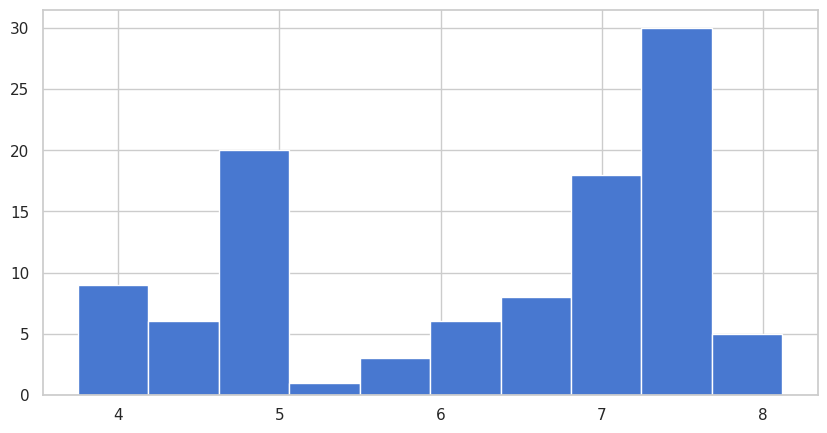

In [ ]:
# refer back to Section 7 if you need a hint
pka["220"].hist()

# show the plot
plt.show()

### Challenge 5

Show the change in the pka of the active site amino acid with time. The code has been partially started.

Text(0, 0.5, 'pKa value')

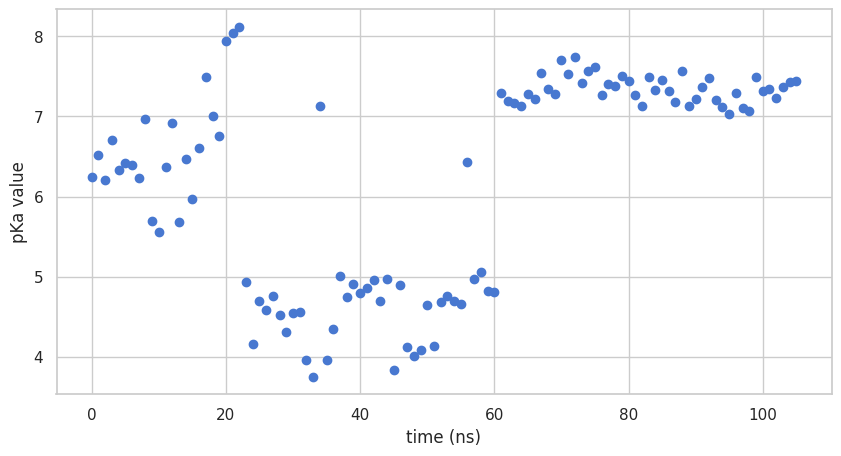

In [ ]:

# define which columns contains the x and y values
plt.scatter(x = pka['time'], y = pka["220"])

# label the x axis
plt.xlabel("time (ns)")

# label the y axis
plt.ylabel("pKa value")

### Challenge 6
Create a new categorical column called `histidine_status` based on the active site amino acid data. Make three bins:
- **low outlier**: if the value is more than 1 standard deviation below the mean
- **normal**: if the value within the standard deviation of the mean
- **high outlier**: if the value greater than one the standard deviation above the mean


Use your statistical values from Challenge 3 to figure out the bin cutoffs.

In [ ]:
## Refer back to the end of Section 10 for hints on binning data

pka["histidine_status"] = pd.cut(
    pka["220"], # column to categorize
    bins=[0, 6.23-1.3, 6.23+1.3, 8.12], # bin boundaries [min, lower inner, upper inner, max]
    labels=["low_outlier", "normal", "high_outlier"] # bin labels
)

# print the top 30 rows showing pka of 220 and histidine_status
print(pka[["220", "histidine_status"]].head(30))

         220 histidine_status
0   6.239502           normal
1   6.513632           normal
2   6.208628           normal
3   6.710703           normal
4   6.326954           normal
5   6.412602           normal
6   6.389446           normal
7   6.225451           normal
8   6.970473           normal
9   5.697994           normal
10  5.562929           normal
11  6.368852           normal
12  6.914140           normal
13  5.680709           normal
14  6.467865           normal
15  5.969034           normal
16  6.607760           normal
17  7.487896           normal
18  6.999304           normal
19  6.755731           normal
20  7.935826     high_outlier
21  8.042743     high_outlier
22  8.119895     high_outlier
23  4.937320           normal
24  4.157841      low_outlier
25  4.690152      low_outlier
26  4.581546      low_outlier
27  4.759376      low_outlier
28  4.518202      low_outlier
29  4.314122      low_outlier


### Challenge 7

Use seaborn to create the scatterplot colored by `histidine_status`. The code has been partially completed, `hue` indicates which column should be used to color the points. Notice the different syntax used in seaborn to indicate columns.

<Axes: xlabel='time', ylabel='220'>

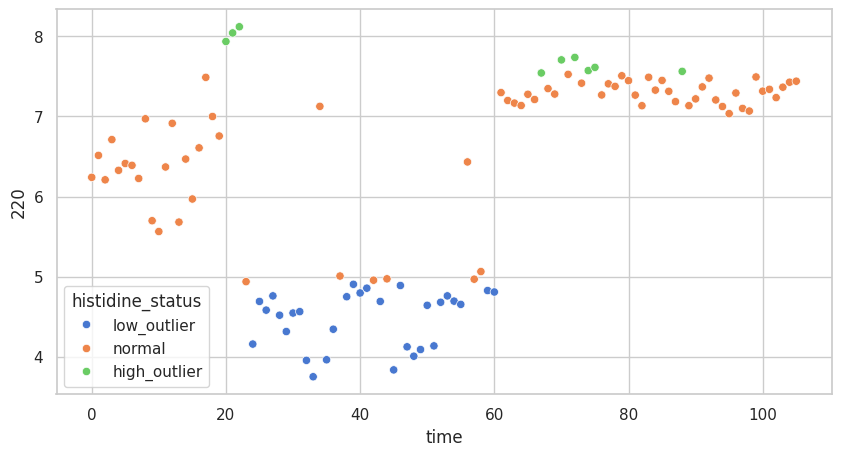

In [ ]:
sns.scatterplot(data = pka, x = 'time', y = '220', hue = 'histidine_status')